# 6. Competing-risks absolute risk

Analysis C addresses the estimand that analyses A and B deliberately leave
aside: the absolute risk of cardiac death in the presence of non-cardiac
death, on the full time-to-event cohort. The target is the cardiac cumulative
incidence `F1(t)`, in which a competing death is an event of the population
process, not censoring. Two cause-specific Cox models per feature set, one for
cardiac and one for non-cardiac death, are combined through their Breslow
baselines into a per-patient `F1(t)`; censoring the competing cause inside
each cause-specific fit is the definition of the cause-specific hazard, and
the competing-risk correction happens at the combination step.

Ranking is still scored cause-specifically, as in analysis B, so the paired
thyroid contrast stays comparable across analyses; the absolute scale is
checked against Aalen-Johansen within groups of predicted risk. The outer
folds are shared by every feature set, so every contrast remains paired.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import survival as surv
import utils

utils.ensure_dirs()
utils.set_seed()
HORIZONS = [float(h) for h in config.HORIZONS]
print("horizons:", HORIZONS, "| outer folds:", config.OUTER_CV,
      "| bootstrap:", config.BOOTSTRAP)

horizons: [7.0, 10.0] | outer folds: 5 | bootstrap: 2000


In [2]:
cohort = utils.read_frame(config.COHORT_SURVIVAL)
frame = surv.competing_frame(cohort)
counts = frame["cause_code"].value_counts().sort_index()
print(f"patients: {len(frame)} | censored alive: {counts.get(0, 0)} | "
      f"cardiac deaths: {counts.get(1, 0)} | "
      f"non-cardiac deaths: {counts.get(2, 0)}")

patients: 8063 | censored alive: 5656 | cardiac deaths: 1008 | non-cardiac deaths: 1399


## 6.1 Shared folds

Folds are stratified on the three-level cause code, so each fold carries its
share of both event types, and the same assignment is reused by every feature
set.

In [3]:
folds = utils.make_folds(frame["cause_code"].to_numpy(), config.OUTER_CV)
for k, (tr, te) in enumerate(folds):
    codes = frame["cause_code"].to_numpy()[te]
    print(f"fold {k}: test {len(te)}, cardiac {(codes == 1).sum()}, "
          f"non-cardiac {(codes == 2).sum()}")

fold 0: test 1613, cardiac 201, non-cardiac 280
fold 1: test 1613, cardiac 202, non-cardiac 280
fold 2: test 1613, cardiac 202, non-cardiac 280
fold 3: test 1612, cardiac 202, non-cardiac 279
fold 4: test 1612, cardiac 201, non-cardiac 280


## 6.2 Cause-specific models and out-of-fold incidence

The Cox pipelines carry no tuned hyperparameters, so per-fold refits are
cheap and need no cache.

In [4]:
results = {}
for feature_set in config.FEATURE_SETS:
    X = frame[utils.feature_list(feature_set)].copy()
    results[feature_set] = surv.evaluate_cif_cv(X, frame, folds, HORIZONS)

folds_table = pd.concat(
    [results[fs]["folds"].assign(feature_set=fs) for fs in results],
    ignore_index=True)
cv_summary = (folds_table.groupby(["feature_set", "horizon"])
              .agg(c_harrell_mean=("c_harrell", "mean"),
                   c_harrell_std=("c_harrell", "std"),
                   c_uno_mean=("c_uno", "mean"),
                   c_uno_std=("c_uno", "std"),
                   mean_predicted_cif=("mean_predicted_cif", "mean"))
              .reset_index())
utils.save_result(cv_summary, "competing_cif_cv_summary")
cv_summary.round(4)

,feature_set,horizon,c_harrell_mean,c_harrell_std,c_uno_mean,c_uno_std,mean_predicted_cif
0,CV17,7.0,0.7877,0.0051,0.7842,0.0088,0.1185
1,CV17,10.0,0.7846,0.0053,0.7769,0.0110,0.1505
2,CV17_THY_CONT,7.0,0.7892,0.0054,0.7860,0.0101,0.1179
3,CV17_THY_CONT,10.0,0.7853,0.0058,0.7777,0.0121,0.1496
4,CV17_THY_CONT_RATIO,7.0,0.7886,0.0052,0.7855,0.0100,0.1180
5,CV17_THY_CONT_RATIO,10.0,0.7846,0.0057,0.7770,0.0123,0.1497
6,CV17_THY_CONT_STATES,7.0,0.7917,0.0045,0.7877,0.0074,0.1176
7,CV17_THY_CONT_STATES,10.0,0.7879,0.0043,0.7782,0.0094,0.1486
8,CV17_THY_STATES,7.0,0.7920,0.0044,0.7876,0.0072,0.1180
9,CV17_THY_STATES,10.0,0.7883,0.0037,0.7786,0.0090,0.1492


## 6.3 Paired thyroid contrast

The score is the out-of-fold predicted incidence at each horizon, on
identical patients and folds. Follow-up is administratively censored at the
evaluated horizon, so the concordance refers to the same horizon as the
score. The out-of-fold pairing caveat of analysis B applies unchanged:
the patient-level bootstrap does not account for the dependence induced
by shared training folds and may underestimate uncertainty.

In [5]:
def score_frame(feature_set, horizon):
    truncated = surv.survival_frame(frame, horizon)
    return truncated[[config.ID_COL, "surv_time", "surv_event"]].assign(
        cif=results[feature_set]["oof_cif"][horizon])

delta_rows = []
for horizon in HORIZONS:
    base = score_frame(config.PRIMARY_BASELINE, horizon)
    for feature_set in config.FEATURE_SETS:
        if feature_set == config.PRIMARY_BASELINE:
            continue
        role = ("primary" if feature_set == config.PRIMARY_THYROID
            else "secondary")
        delta_rows.append({
            "horizon": horizon, "thyroid_set": feature_set,
            "comparison_role": role,
            **surv.paired_cindex_delta(base,
                                       score_frame(feature_set, horizon),
                                       score_col="cif")})
cif_delta = pd.DataFrame(delta_rows)
cif_delta["q_bh"] = np.nan
secondary = cif_delta["comparison_role"] == "secondary"
for horizon in HORIZONS:
    mask = secondary & (cif_delta["horizon"] == horizon)
    if mask.any():
        cif_delta.loc[mask, "q_bh"] = utils.benjamini_hochberg(
            cif_delta.loc[mask, "p_bootstrap"].fillna(1.0))
utils.save_result(cif_delta, "competing_cif_delta")
cif_delta.round(4)

,horizon,thyroid_set,comparison_role,delta_c_index,ci_lo,ci_hi,p_bootstrap,n_boot_used,excludes_zero,q_bh
0,7.0,CV17_THY_CONT,primary,0.0014,-0.0011,0.0034,0.243,2000,False,NaN
1,7.0,CV17_THY_STATES,secondary,0.0042,0.0011,0.0075,0.009,2000,True,0.0270
2,7.0,CV17_THY_CONT_STATES,secondary,0.0039,0.0003,0.0075,0.035,2000,True,0.0525
3,7.0,CV17_THY_CONT_RATIO,secondary,0.0009,-0.0018,0.0029,0.437,2000,False,0.4370
4,10.0,CV17_THY_CONT,primary,0.0007,-0.0017,0.0026,0.495,2000,False,NaN
5,10.0,CV17_THY_STATES,secondary,0.0038,0.0009,0.0071,0.012,2000,True,0.0360
6,10.0,CV17_THY_CONT_STATES,secondary,0.0032,-0.0002,0.0067,0.073,2000,False,0.1095
7,10.0,CV17_THY_CONT_RATIO,secondary,-0.0000,-0.0025,0.0020,0.930,2000,False,0.9300


## 6.4 Absolute-risk calibration against Aalen-Johansen

Predicted incidence is averaged within quintiles of itself and compared with
the Aalen-Johansen estimate on the same patients. The non-parametric
reference must be Aalen-Johansen: `1 - Kaplan-Meier` censors the competing
deaths and would overstate every observed value, which is the estimand error
this analysis exists to avoid. A tertile split of the same predictions is
saved as the stratification view.

In [6]:
blocks = []
for feature_set in (config.PRIMARY_BASELINE, config.PRIMARY_THYROID):
    for horizon in HORIZONS:
        table = surv.cif_calibration(
            frame, results[feature_set]["oof_cif"][horizon], horizon)
        blocks.append(table.assign(feature_set=feature_set, horizon=horizon))
cif_calibration = pd.concat(blocks, ignore_index=True)
cif_calibration["observed_to_predicted"] = (
    cif_calibration["observed_cif_aalen_johansen"]
    / cif_calibration["mean_predicted_cif"])
utils.save_result(cif_calibration, "competing_cif_calibration")
cif_calibration.round(4)

,group,n,mean_predicted_cif,observed_cif_aalen_johansen,events_cardiac,events_noncardiac,feature_set,horizon,observed_to_predicted
0,1,1613,0.0183,0.0198,38,75,CV17,7.0,1.0801
1,2,1612,0.0431,0.0383,71,141,CV17,7.0,0.8895
2,3,1613,0.0767,0.0732,144,275,CV17,7.0,0.9553
3,4,1612,0.1354,0.1516,267,405,CV17,7.0,1.1197
4,5,1613,0.3188,0.3087,488,503,CV17,7.0,0.9683
5,overall,8063,0.1184,0.1172,1008,1399,CV17,7.0,0.9898
6,1,1613,0.0267,0.0282,39,73,CV17,10.0,1.0565
7,2,1612,0.0615,0.0542,72,146,CV17,10.0,0.8808
8,3,1613,0.1062,0.1140,147,282,CV17,10.0,1.0741
9,4,1612,0.1779,0.1981,263,413,CV17,10.0,1.1134


In [7]:
stratification = surv.cif_calibration(
    frame, results[config.PRIMARY_BASELINE]["oof_cif"][HORIZONS[0]],
    HORIZONS[0], n_groups=3)
utils.save_result(
    stratification.assign(feature_set=config.PRIMARY_BASELINE,
                          horizon=HORIZONS[0]),
    "competing_cif_stratification")
stratification.round(4)

,group,n,mean_predicted_cif,observed_cif_aalen_johansen,events_cardiac,events_noncardiac
0,1,2688,0.0264,0.0249,83,151
1,2,2687,0.0783,0.0798,250,461
2,3,2688,0.2507,0.2494,675,787
3,overall,8063,0.1184,0.1172,1008,1399


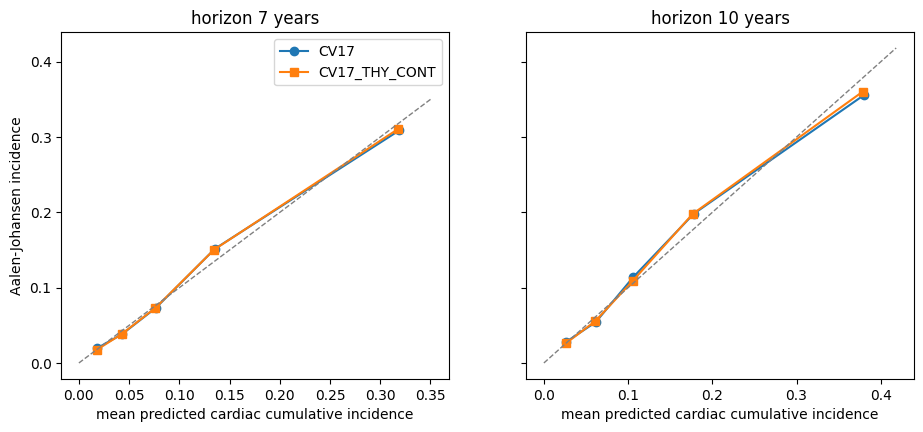

In [8]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(11, 4.5), sharey=True)
for ax, horizon in zip(np.atleast_1d(axes), HORIZONS):
    view = cif_calibration[(cif_calibration["horizon"] == horizon)
                           & (cif_calibration["group"] != "overall")]
    for feature_set, marker in [(config.PRIMARY_BASELINE, "o"),
                                (config.PRIMARY_THYROID, "s")]:
        sub = view[view["feature_set"] == feature_set]
        ax.plot(sub["mean_predicted_cif"],
                sub["observed_cif_aalen_johansen"],
                marker=marker, label=feature_set)
    limit = 1.1 * max(view["mean_predicted_cif"].max(),
                      view["observed_cif_aalen_johansen"].max())
    ax.plot([0, limit], [0, limit], linestyle="--", color="grey",
            linewidth=1)
    ax.set_xlabel("mean predicted cardiac cumulative incidence")
    ax.set_title(f"horizon {horizon:g} years")
np.atleast_1d(axes)[0].set_ylabel("Aalen-Johansen incidence")
np.atleast_1d(axes)[0].legend()
utils.save_fig(fig, "competing_cif_calibration")
plt.show()

In [9]:
utils.write_manifest(
    config.RESULTS_DIR / "competing_risks_manifest.json",
    stage="6_competing_risks",
    estimand="cardiac cumulative incidence with non-cardiac death "
             "as a competing event",
    models="cause-specific Cox per cause, Breslow baselines combined",
    outer_folds=config.OUTER_CV,
    horizons=list(HORIZONS),
    note="Ranking metrics stay cause-specific for comparability with "
         "analysis B; the absolute scale is checked against Aalen-Johansen.")
print("stage complete")

stage complete
